Khai báo thư viện và Tải dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

# Tải dữ liệu
try:
    # Lấy 10,000 dòng để demo nhanh và mượt
    df = pd.read_csv('../data/text/fraudTrain.csv').sample(10000, random_state=42).reset_index(drop=True)
    #df = pd.read_csv('/content/fraudTrain.csv').sample(10000, random_state=42).reset_index(drop=True)
    print("Tải dữ liệu thành công!")
    print(f"Kích thước tập dữ liệu: {df.shape}")
except Exception as e:
    print(f"Lỗi: {e}. Vui lòng kiểm tra lại file đầu vào.")
    df.head()

Tải dữ liệu thành công!
Kích thước tập dữ liệu: (10000, 23)


Kiểm tra và xử lí dữ liệu thiếu

Số lượng giá trị thiếu mỗi cột:
Không có giá trị thiếu.


<Figure size 1000x400 with 0 Axes>

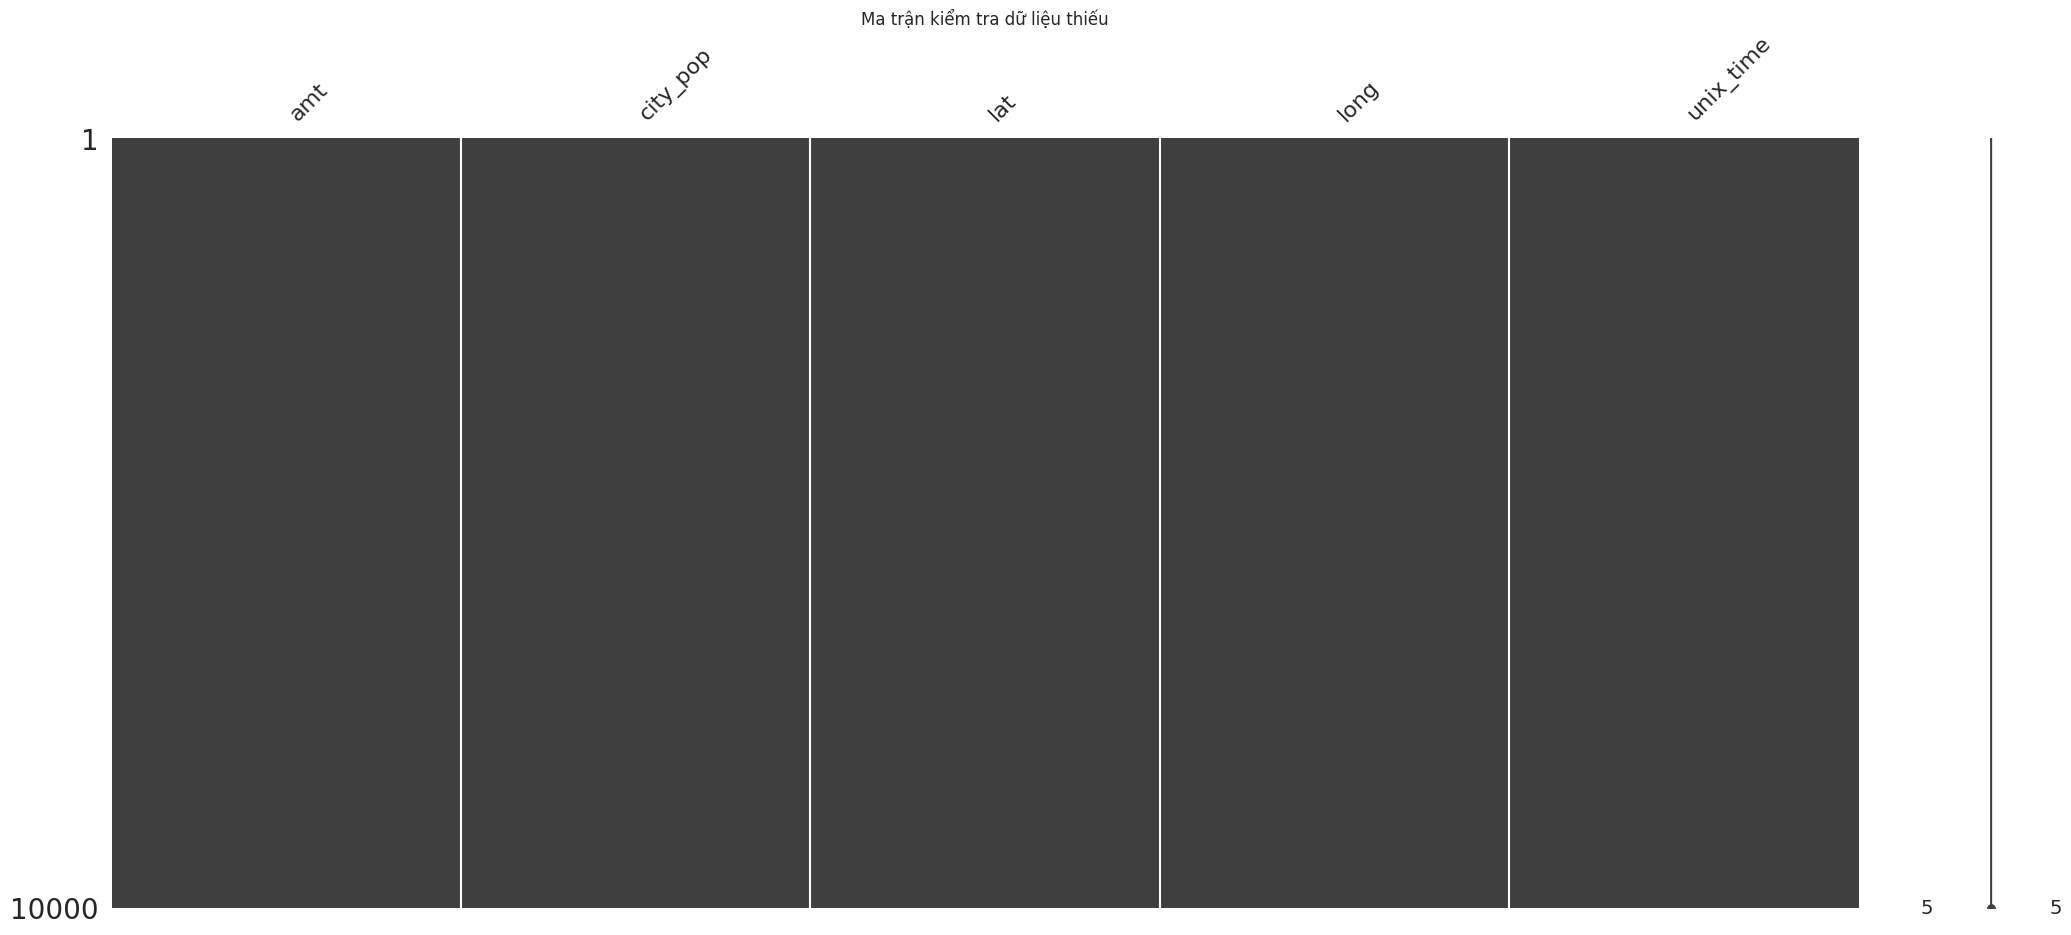

Đã thực thi quy trình Imputation (Median cho 'amt' và KNN cho 'city_pop').


In [ ]:


# 1. Kiểm tra số lượng giá trị thiếu trong từng cột
missing_values = df.isnull().sum()
print("Số lượng giá trị thiếu mỗi cột:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Không có giá trị thiếu.")

# 2. Trực quan hóa mô hình thiếu hụt
plt.figure(figsize=(10, 4))
msno.matrix(df[['amt', 'city_pop', 'lat', 'long', 'unix_time']])
plt.title("Ma trận kiểm tra dữ liệu thiếu")
plt.show()

# 3. Triển khai kỹ thuật Imputation (Để đáp ứng yêu cầu implement của đề bài)
# Chúng ta sẽ áp dụng trực tiếp lên bản sao của df
df_clean = df.copy()

# Giả sử cần xử lý cột 'amt' và 'city_pop'
# (Code này vẫn chạy tốt dù dữ liệu có thiếu hay không)
median_imputer = SimpleImputer(strategy='median')
df_clean['amt'] = median_imputer.fit_transform(df[['amt']])

knn_imputer = KNNImputer(n_neighbors=5)
df_clean['city_pop'] = knn_imputer.fit_transform(df[['city_pop', 'lat', 'long']])[:, 0]

print("Đã thực thi quy trình Imputation (Median cho 'amt' và KNN cho 'city_pop').")


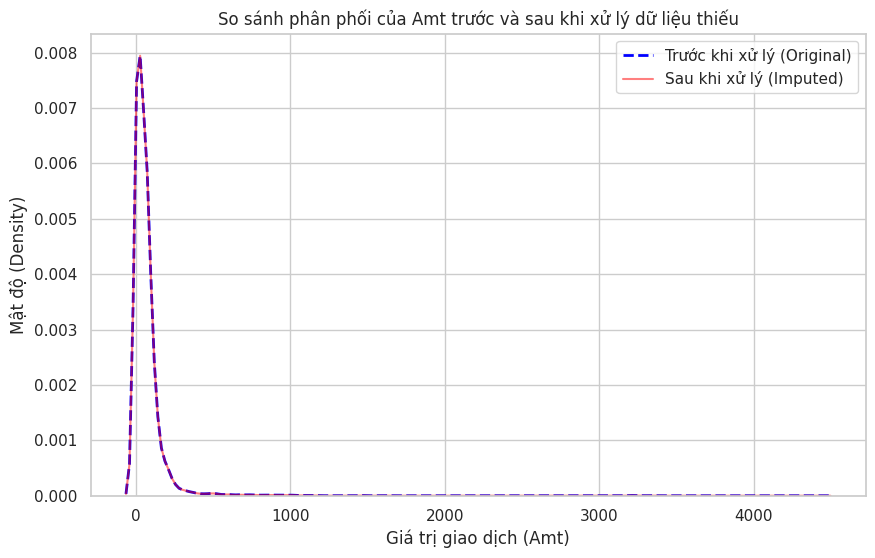

Nhận xét: Hai đường phân phối trùng khớp hoàn toàn vì dữ liệu gốc không có giá trị thiếu.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo khung hình
plt.figure(figsize=(10, 6))

# Vẽ đường phân phối (KDE) cho dữ liệu gốc (trước khi lấp đầy)
sns.kdeplot(df['amt'], label='Trước khi xử lý (Original)', color='blue', linestyle='--', linewidth=2)

# Vẽ đường phân phối (KDE) cho dữ liệu sau khi lấp đầy (Imputed)
sns.kdeplot(df_clean['amt'], label='Sau khi xử lý (Imputed)', color='red', alpha=0.5)

plt.title('So sánh phân phối của Amt trước và sau khi xử lý dữ liệu thiếu')
plt.xlabel('Giá trị giao dịch (Amt)')
plt.ylabel('Mật độ (Density)')
plt.legend()
plt.grid(True)
plt.show()

print("Nhận xét: Hai đường phân phối trùng khớp hoàn toàn vì dữ liệu gốc không có giá trị thiếu.")

Chuẩn hóa dữ liệu

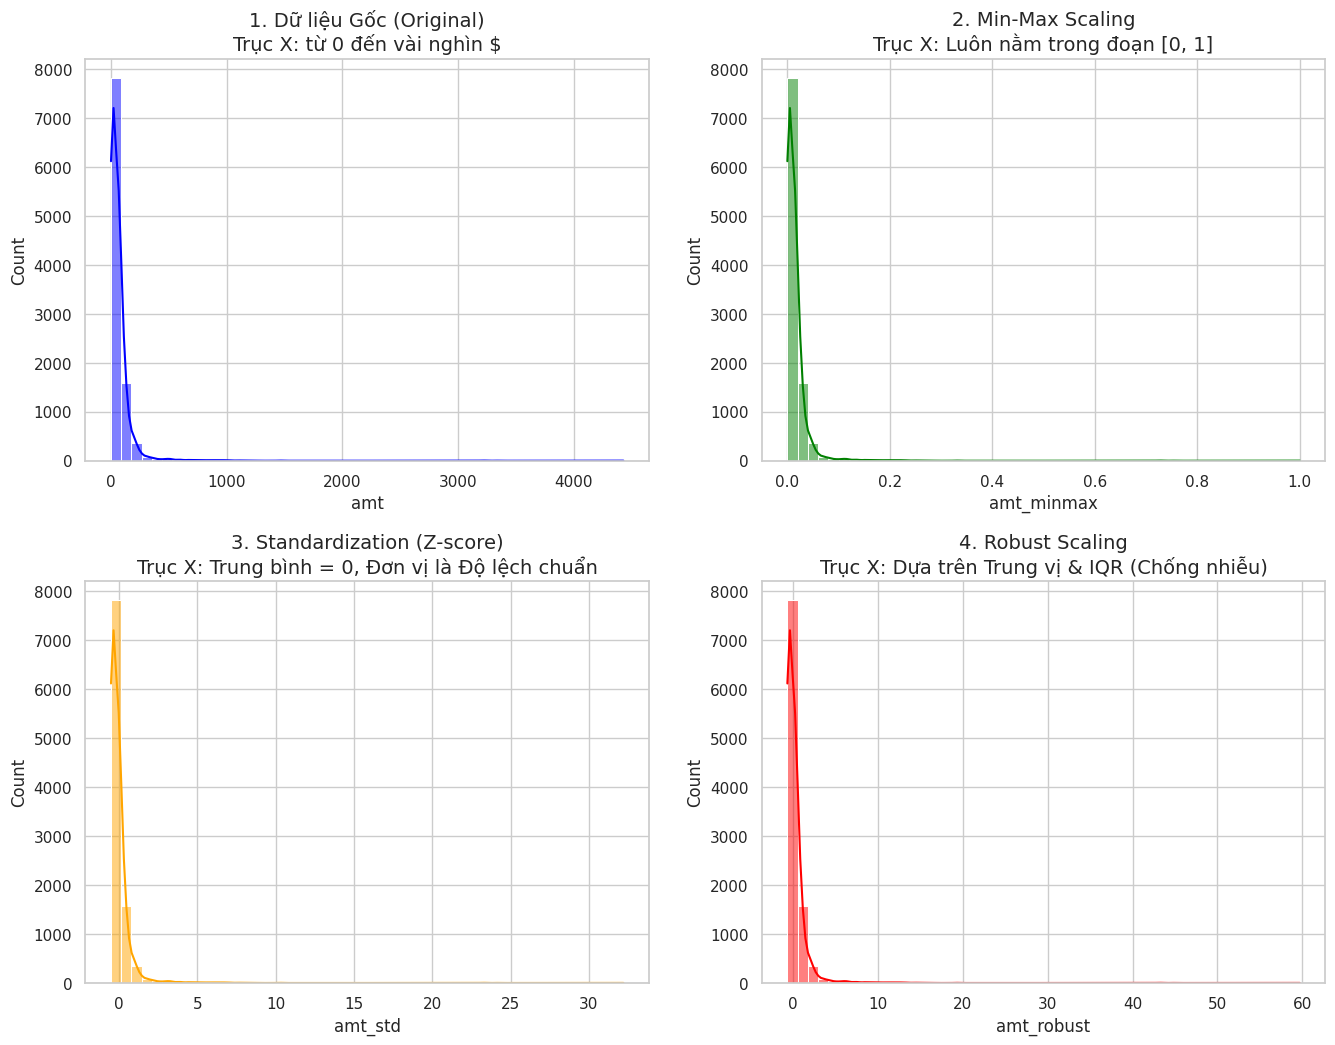

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu
data_to_scale = df_clean[['amt']]

# Áp dụng 3 kỹ thuật
df_clean['amt_minmax'] = MinMaxScaler().fit_transform(data_to_scale)
df_clean['amt_std'] = StandardScaler().fit_transform(data_to_scale)
df_clean['amt_robust'] = RobustScaler().fit_transform(data_to_scale)

# Tạo khung hình
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3)

# 1. Dữ liệu Gốc
sns.histplot(df_clean['amt'], bins=50, ax=axes[0,0], kde=True, color='blue')
axes[0,0].set_title('1. Dữ liệu Gốc (Original)\nTrục X: từ 0 đến vài nghìn $', fontsize=14)

# 2. Min-Max Scaling
sns.histplot(df_clean['amt_minmax'], bins=50, ax=axes[0,1], kde=True, color='green')
axes[0,1].set_title('2. Min-Max Scaling\nTrục X: Luôn nằm trong đoạn [0, 1]', fontsize=14)

# 3. Standardization (Z-score)
sns.histplot(df_clean['amt_std'], bins=50, ax=axes[1,0], kde=True, color='orange')
axes[1,0].set_title('3. Standardization (Z-score)\nTrục X: Trung bình = 0, Đơn vị là Độ lệch chuẩn', fontsize=14)

# 4. Robust Scaling
sns.histplot(df_clean['amt_robust'], bins=50, ax=axes[1,1], kde=True, color='red')
axes[1,1].set_title('4. Robust Scaling\nTrục X: Dựa trên Trung vị & IQR (Chống nhiễu)', fontsize=14)

plt.show()



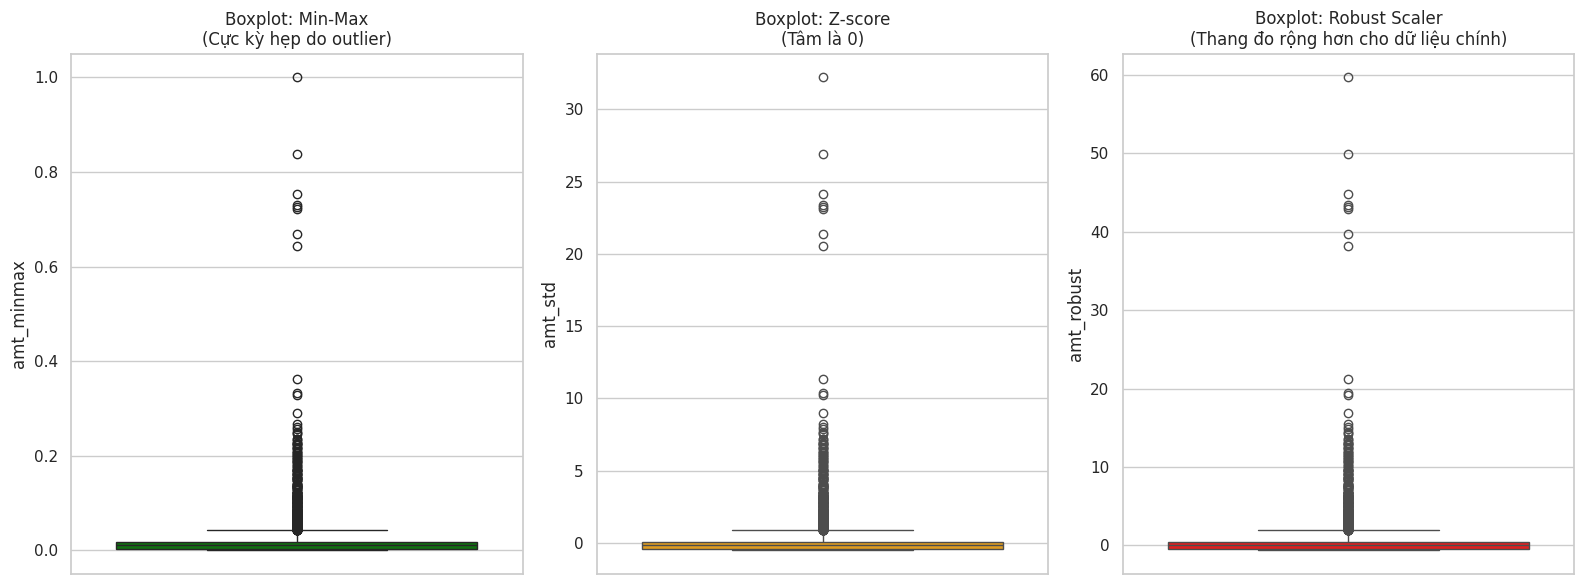

In [ ]:
# Vẽ Boxplot riêng biệt để thấy rõ "Hộp" dữ liệu
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean['amt_minmax'], color='green')
plt.title('Boxplot: Min-Max\n(Cực kỳ hẹp do outlier)')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_clean['amt_std'], color='orange')
plt.title('Boxplot: Z-score\n(Tâm là 0)')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_clean['amt_robust'], color='red')
plt.title('Boxplot: Robust Scaler\n(Thang đo rộng hơn cho dữ liệu chính)')

plt.tight_layout()
plt.show()

Mã hóa biến phân loại

In [ ]:


# 1. One-hot Encoding cho biến Nominal ít nhóm (gender)
df_clean = pd.get_dummies(df_clean, columns=['gender'], prefix='gen')

# 2. Xử lý High-cardinality (Biến có quá nhiều nhóm)
# Ví dụ: Cột 'merchant' hoặc 'job' có hàng trăm giá trị khác nhau
print(f"Số lượng Merchant duy nhất: {df_clean['merchant'].nunique()}")
print(f"Số lượng Category duy nhất: {df_clean['category'].nunique()}")

# Chiến lược: Frequency Encoding (Mã hóa theo tần suất xuất hiện)
# Phù hợp cho biến 'merchant' vì tần suất giao dịch tại một cửa hàng có thể liên quan đến gian lận
merchant_freq = df_clean['merchant'].value_counts(normalize=True)
df_clean['merchant_freq_enc'] = df_clean['merchant'].map(merchant_freq)

# Chiến lược: Target Encoding (Mã hóa theo tỷ lệ gian lận - 'is_fraud')

category_fraud_rate = df_clean.groupby('category')['is_fraud'].mean()
df_clean['category_target_enc'] = df_clean['category'].map(category_fraud_rate)

# Hiển thị kết quả sau mã hóa
print("\nKết quả mã hóa các biến quan trọng:")
display(df_clean[['merchant', 'merchant_freq_enc', 'category', 'category_target_enc']].head())

print("\nToàn bộ các cột hiện có trong dataset sau tiền xử lý:")
print(df_clean.columns.tolist())

Số lượng Merchant duy nhất: 692
Số lượng Category duy nhất: 14

Kết quả mã hóa các biến quan trọng:


,merchant,merchant_freq_enc,category,category_target_enc
0,fraud_Towne LLC,0.0017,misc_pos,0.003215
1,fraud_Friesen Ltd,0.0012,health_fitness,0.000000
2,fraud_Mohr Inc,0.0021,shopping_pos,0.009730
3,fraud_Gaylord-Powlowski,0.0018,home,0.002055
4,"fraud_Christiansen, Goyette and Schamberger",0.0022,gas_transport,0.007744



Toàn bộ các cột hiện có trong dataset sau tiền xử lý:
['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt', 'first', 'last', 'street', 'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud', 'amt_minmax', 'amt_std', 'amt_robust', 'gen_F', 'gen_M', 'merchant_freq_enc', 'category_target_enc']


--- 2.2.2 d) Lựa chọn đặc trưng (Đã loại bỏ biến dư thừa) ---


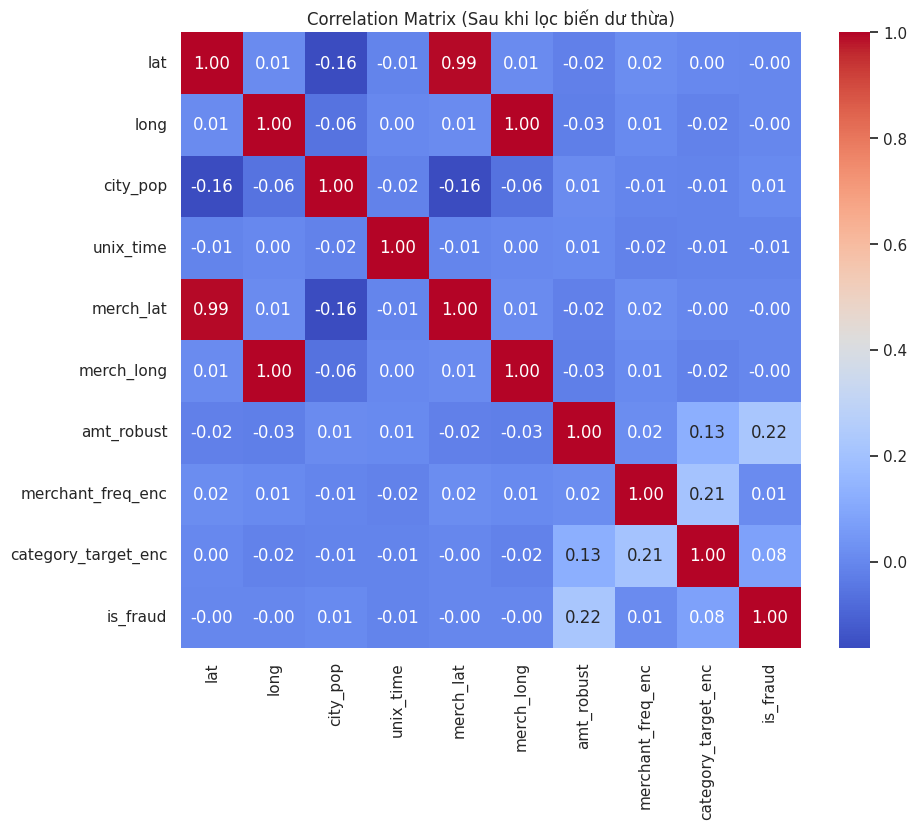

In [ ]:
print("--- 2.2.2 d) Lựa chọn đặc trưng (Đã loại bỏ biến dư thừa) ---")

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
# Loại bỏ các cột định danh VÀ các biến số tiền dư thừa (chỉ giữ lại amt_robust)
cols_to_drop = [
    'Unnamed: 0', 'cc_num', 'first', 'last', 'street', 'city', 'state', 'zip',
    'trans_num', 'dob', 'trans_date_trans_time', 'merchant', 'job', 'category',
    'amt', 'amt_minmax', 'amt_std' # Xóa các biến tiền khác để tránh đa cộng tuyến
]

# Tạo bản sao và làm sạch nhãn NaN
df_fs = df_clean.copy().dropna(subset=['is_fraud'])

# Tách X và y
X = df_fs.drop(columns=[col for col in cols_to_drop if col in df_fs.columns] + ['is_fraud'])
y = df_fs['is_fraud']

# Chỉ lấy các cột kiểu số
X = X.select_dtypes(include=[np.number]).fillna(X.median())

# Ma trận tương quan
plt.figure(figsize=(10, 8))
cor = pd.concat([X, y], axis=1).corr()
sns.heatmap(cor, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix (Sau khi lọc biến dư thừa)")
plt.show()



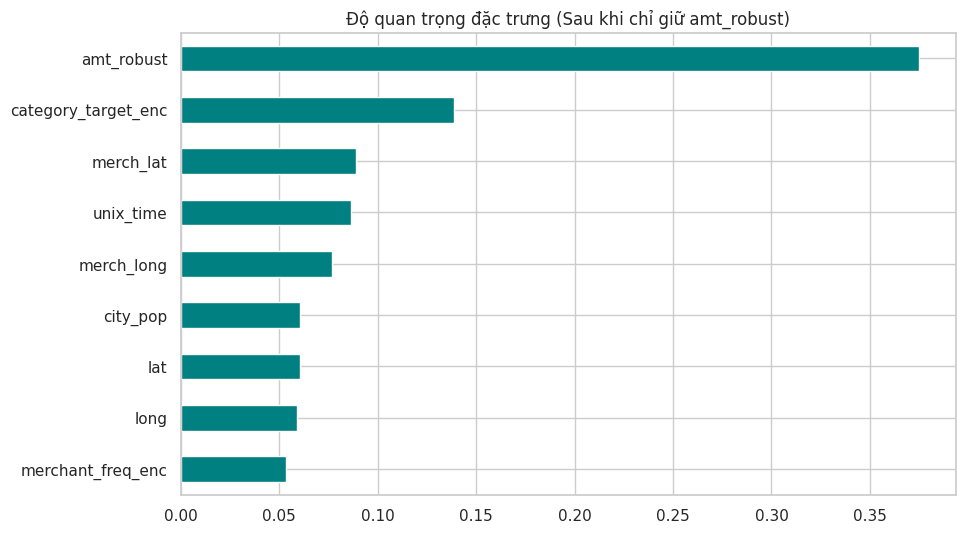

In [ ]:
# Feature Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title("Độ quan trọng đặc trưng (Sau khi chỉ giữ amt_robust)")
plt.show()
